# 08 — Perfect-quality lab: beyond "good"

Notebook 07 fixed the obvious problems. This one chases **maximum reading quality with
unlimited compute** — new experiments run 2026-06-07, plus a researched roadmap of
tools we haven't integrated yet.

## What was tried here (results below)

| Experiment | Result | Verdict |
|---|---|---|
| §1 Sauvola/Wolf binarization on 2×/4× cubic-upscaled grayscale | ≈ ScanTailor@600; 1200dpi mask marginally smoothest | plain interpolation is exhausted — real gains need **neural SR** |
| §2 `recode_pdf` facsimile profile (`--bg-downsample 1`, rates 50/150 vs default 500/750) | **V5**: visibly cleaner tones & photos, text gain small; 25 MB vs 4 MB | adopt for figure-heavy books / `--hq-pages`; overkill for plain text |
| §3 potrace vector glyphs from the 1200dpi mask | **perfectly smooth at any zoom** — the quality ceiling | the headline prize; needs engineering (see roadmap #6) |

## Research digest (sources in the roadmap section)

* **PERO-OCR** (Brno Univ. of Technology + Moravian Library) is built *specifically for
  Czech/Slovak print*, exports ALTO/PAGE-XML with word geometry — the most relevant OCR
  upgrade for this corpus, self-hostable via `pip install pero-ocr`.
* **Premium libraries don't binarize**: HathiTrust/e-rara-style facsimile = high-rate
  JPEG2000 of the full tone page + invisible text layer. Our V4/V5 path is that style;
  V2's binarized mask is the IA/DjVu style. Both are legitimate "perfect" targets —
  **decide which the readers want** (or ship V2 + per-book V5 for figure-heavy titles).
* **SR-before-binarization** is literature-validated (+~4 dB on H-DIBCO'18, large OCR
  gains) but needs *document-specific* models (TextBSR, task-driven SR) — generic
  Real-ESRGAN/SwinIR hallucinate on glyphs. License caution: TextBSR is CC-BY-NC.
* **NAF-DPM** (diffusion, 2024) is the current binarization SOTA (DIBCO19) and also
  denoises/deblurs in the same pass — candidate to replace ScanTailor's thresholding.
* **UVDoc** is the line-straightness champion among dewarpers — straight lines are a
  big perceived-quality driver and our spines still curve slightly.
* **Vector-glyph PDFs** (Adobe ClearScan-style): only open-source attempt is
  **smoothscan** (glyph clustering → potrace → embedded TrueType; alpha, unmaintained).
  §3 demonstrates the payoff; reviving it is the highest-effort/highest-ceiling item.
* **LLM-OCR** (olmOCR-2, Mistral OCR): great text, **no reliable word boxes** — use
  only as post-OCR diacritic corrector over PERO/Tesseract geometry, never as the
  text-layer source.

In [1]:
%load_ext autoreload
%autoreload 2

import subprocess
from pathlib import Path

import cv2
import doxapy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypdfium2 as pdfium

PROTO_DIR = Path("../output/prototypes").resolve()
LAB07 = Path("../output/lab07").resolve()
LAB08 = Path("../output/lab08").resolve()
LAB08.mkdir(parents=True, exist_ok=True)

# a representative dense-text page from the notebook-07 intermediates
GRAY_PAGE = next(iter(sorted((LAB07 / "V3_gray_mrc" / "st_pages").glob("*p0004_1.tif"))))
ST600_PAGE = next(iter(sorted((LAB07 / "V2_mixed600" / "st_pages").glob("*p0004_1.tif"))))
GRAY_PAGE.name, ST600_PAGE.name

('OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV_p0004_1.tif',
 'OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV_p0004_1.tif')

## §1 Can classic binarization on upscaled grayscale beat ScanTailor@600?

Sauvola and Wolf (Doxa) on bicubic 2× (600dpi) and 4× (1200dpi) upsampled pages,
vs ScanTailor's own supersampled binarization. **Finding:** all comparable at reading
zoom; the 1200dpi Sauvola mask is marginally the smoothest but bicubic interpolation
adds no new stroke information — this road is exhausted without neural SR.

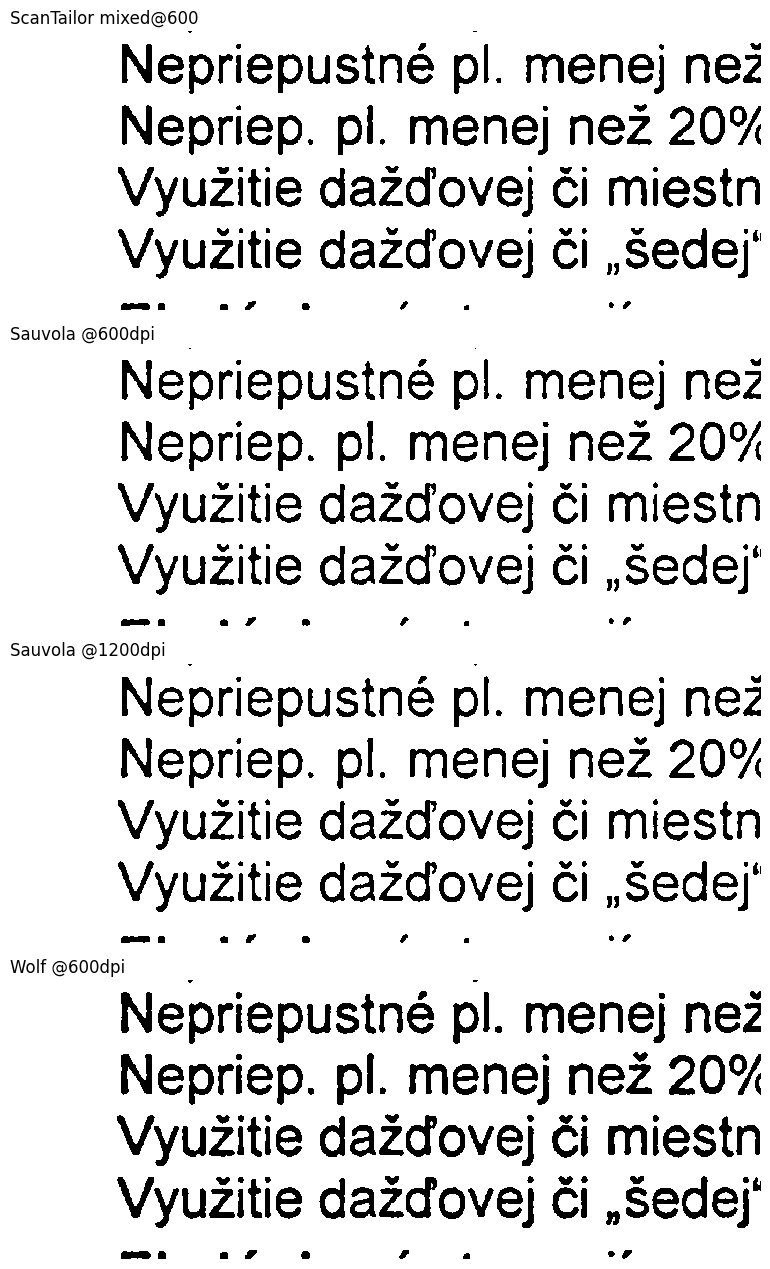

In [2]:
def binarize(img, algo, window, k=0.18):
    result = np.empty(img.shape, np.uint8)
    b = doxapy.Binarization(algo)
    b.initialize(img)
    b.to_binary(result, {"window": window, "k": k})
    return result


gray = cv2.imread(str(GRAY_PAGE), cv2.IMREAD_GRAYSCALE)
masks = {"ScanTailor mixed@600": (cv2.imread(str(ST600_PAGE), cv2.IMREAD_GRAYSCALE), 2)}
for scale, label in [(2, "600dpi"), (4, "1200dpi")]:
    up = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    masks[f"Sauvola @{label}"] = (binarize(up, doxapy.Binarization.Algorithms.SAUVOLA, 30 * scale + 1), scale)
masks["Wolf @600dpi"] = (
    binarize(cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC),
             doxapy.Binarization.Algorithms.WOLF, 61),
    2,
)

# same physical crop from each (coords are at 300dpi, scaled per mask)
x, y, w, h = 350, 860, 700, 260
fig, axes = plt.subplots(len(masks), 1, figsize=(14, 3.2 * len(masks)))
for ax, (name, (mask, s)) in zip(np.atleast_1d(axes), masks.items()):
    s_eff = mask.shape[1] / gray.shape[1]  # actual scale vs 300dpi page
    crop = mask[int(y * s_eff) : int((y + h) * s_eff), int(x * s_eff) : int((x + w) * s_eff)]
    ax.imshow(crop, cmap="gray", interpolation="nearest")
    ax.set_title(name, loc="left")
    ax.axis("off")
plt.tight_layout()

## §2 Facsimile-quality MRC: V5

`recode_pdf` defaults compress the background **500:1** and foreground 750:1 — that's
the "softness" in V4. The facsimile profile (used for the prebuilt
`output/prototypes/fad_V5_facsimile.pdf`, 25 MB vs V4's 4 MB):

```
recode_pdf -I 'pages/*.tif' -T book.hocr -o out.pdf -D 300 \
  --mask-compression jbig2 -J openjpeg \
  --bg-downsample 1 --denoise-mask none \
  --bg-compression-flags='-r 50' --fg-compression-flags='-r 150'
```

Text gain is small (text lives in the lossless mask); **tones, stamps and photos gain
visibly**. Production idea: keep defaults for text books, switch to this profile (or
`--hq-pages` with `--hq-*-compression-flags`) for books flagged figure-heavy by the
notebook-07 inventory.

In [3]:
variants = {p.stem.split("_", 1)[1]: p for p in sorted(PROTO_DIR.glob("fad_V*.pdf"))}
pd.DataFrame(
    [{"variant": n, "mb": round(p.stat().st_size / 1e6, 1)} for n, p in variants.items()]
)

,variant,mb
0,V1_mixed300,1.8
1,V2_mixed600,3.3
2,V3_gray_mrc,4.1
3,V4_gray_docres,4.1
4,V5_facsimile,25.4


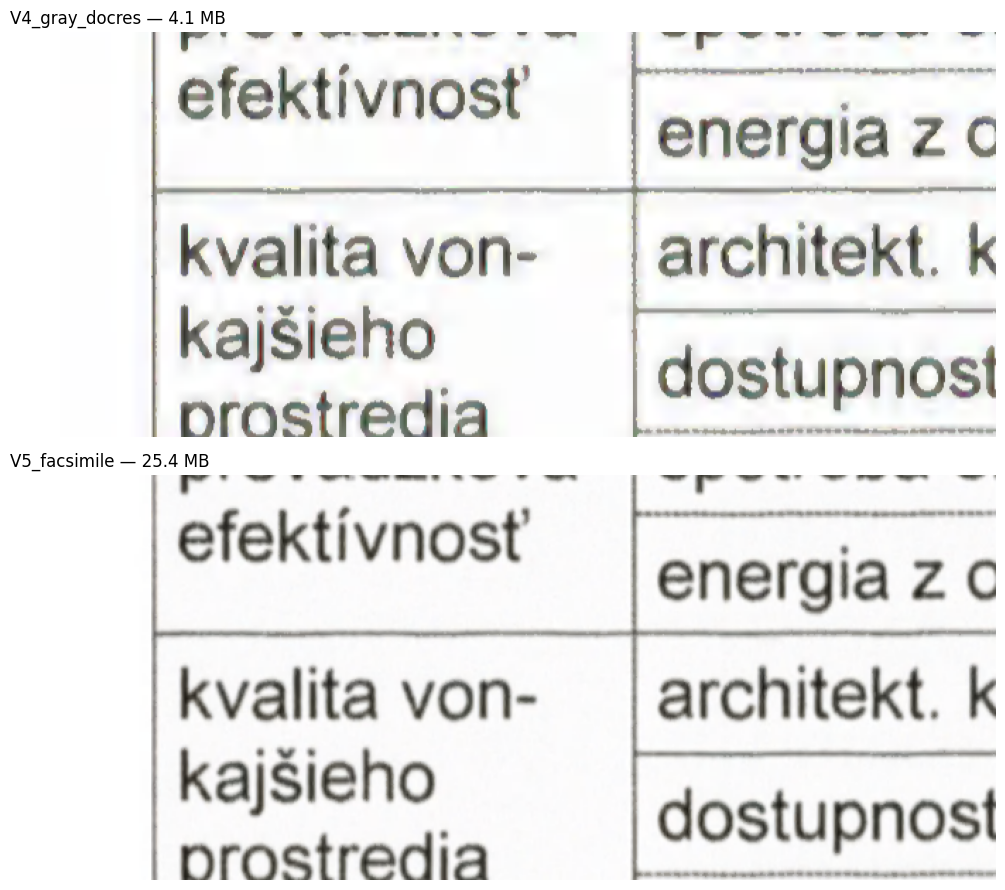

In [4]:
# V4 (default rates) vs V5 (facsimile) — same crop, 3x
PAGE, CROP = 11, (0.15, 0.27, 0.45, 0.36)
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, name in zip(axes, ["V4_gray_docres", "V5_facsimile"]):
    img = pdfium.PdfDocument(str(variants[name]))[PAGE].render(scale=300 / 72).to_pil()
    w, h = img.size
    x0, y0, x1, y1 = CROP
    ax.imshow(img.crop((int(w * x0), int(h * y0), int(w * x1), int(h * y1))), cmap="gray")
    ax.set_title(f"{name} — {variants[name].stat().st_size / 1e6:.1f} MB", loc="left")
    ax.axis("off")
plt.tight_layout()

## §3 The ceiling: vector glyphs (ClearScan-style)

Adobe ClearScan traces every glyph into a font — text stays razor sharp at *any* zoom.
Open-source building blocks exist: **potrace** (bitmap → Bézier) and **smoothscan**
(glyph clustering → potrace → embedded TrueType; alpha quality, unmaintained).

The demo below vectorizes a strip of the 1200dpi Sauvola mask. At 10× zoom the bitmap
shows staircase pixels; the vector version is geometrically smooth forever
(`output/prototypes/vector_glyph_teaser.png` has the prebuilt comparison).
Requires `brew install potrace`.

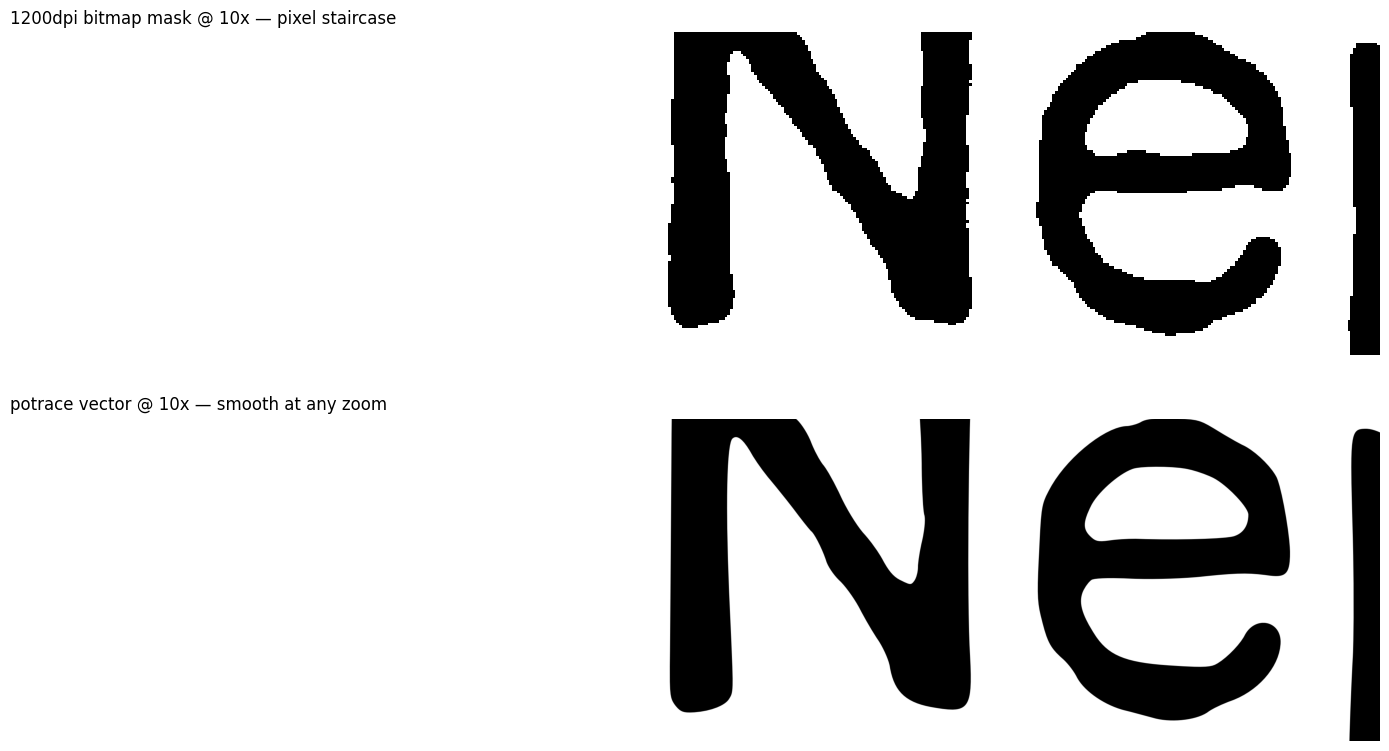

In [5]:
up = cv2.resize(gray, None, fx=4, fy=4, interpolation=cv2.INTER_CUBIC)
mask1200 = binarize(up, doxapy.Binarization.Algorithms.SAUVOLA, 121)
strip = mask1200[3440:4480, 1400:4200]
pbm = LAB08 / "strip.pbm"
cv2.imwrite(str(pbm), strip)
vec_pdf = LAB08 / "strip_vector.pdf"
subprocess.run(
    ["potrace", str(pbm), "-b", "pdf", "-o", str(vec_pdf), "--turdsize", "4"], check=True
)

vec_img = pdfium.PdfDocument(str(vec_pdf))[0].render(scale=8).to_pil()
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].imshow(strip[315:435, 170:680], cmap="gray", interpolation="nearest")
axes[0].set_title("1200dpi bitmap mask @ 10x — pixel staircase", loc="left")
vw = vec_img.size[0] / strip.shape[1]
axes[1].imshow(
    np.array(vec_img.crop((int(170 * vw), int(315 * vw), int(680 * vw), int(435 * vw)))),
    cmap="gray",
)
axes[1].set_title("potrace vector @ 10x — smooth at any zoom", loc="left")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## §4 Roadmap — prioritized experiments (gain ÷ effort)

| # | Experiment | Effort | Expected gain | Notes |
|---|---|---|---|---|
| 1 | **PERO-OCR pilot** ([github.com/DCGM/pero-ocr](https://github.com/DCGM/pero-ocr)) — replace Tesseract for the text layer | low | high (Slovak accuracy + diacritics) | `pip install pero-ocr`, ALTO out → convert to hOCR for `recode_pdf`; hosted API at pero-ocr.fit.vutbr.cz for a zero-setup benchmark |
| 2 | **Reading-experience post-processor**: auto-bookmarks from OCR headings + roman/arabic page labels (pikepdf) + `qpdf --linearize` + veraPDF check | med | high — books *feel* digitized | no turnkey tool exists; script over hOCR headings |
| 3 | **UVDoc dewarp A/B** ([github.com/tanguymagne/UVDoc](https://github.com/tanguymagne/UVDoc)) vs ScanTailor auto | low-med | med-high (line straightness near spine) | GPU; benchmark on sjf/mtf curved pages |
| 4 | **NAF-DPM binarization** ([github.com/ispamm/NAF-DPM](https://github.com/ispamm/NAF-DPM)) replacing ST threshold | med | med-high (DIBCO19 SOTA stroke edges + denoise) | diffusion, GPU; check license |
| 5 | **Neural SR → binarize at 1200dpi**: TextBSR ([github.com/csxmli2016/textbsr](https://github.com/csxmli2016/textbsr), ⚠ CC-BY-NC) or task-driven document SR | med | med-high if diacritics survive | §1 showed interpolation is exhausted; this is the proper test |
| 6 | **Vector-glyph facsimile**: revive smoothscan ([github.com/ncraun/smoothscan](https://github.com/ncraun/smoothscan)) — glyph clustering → potrace → embedded font + invisible text layer | high | **highest ceiling** (§3 demo) | alpha/unmaintained; read OCRmyPDF issue #212 first |
| 7 | **LLM post-OCR correction** (olmOCR-2 / local VLM) over PERO/Tesseract output | med | med (diacritic fixes) | corrector only — LLMs don't give reliable word boxes |
| 8 | **Uni-DocDiff** (ACM MM 2025) — DocRes successor, watch for released weights | n/a | unknown | unified diffusion restoration |

**Two "perfect" products to choose between** (or ship both):

* **Crisp digital edition** — V2 mask path upgraded by #4/#5, eventually #6 for
  vector text. Smallest files, sharpest text, B/W aesthetic.
* **True facsimile** — V4/V5 tone path upgraded by #1/#3, facsimile `recode_pdf`
  profile for figure-heavy books. Looks like the physical book.

License watchlist before production: TextBSR (CC-BY-NC), MARCONet (NC), Surya weights
(OpenRAIL-M), PERO-OCR + NAF-DPM (verify repo LICENSE), archive-pdf-tools (AGPL —
fine as external CLI).